# Formula 1 Race State Visualizer & Multi-Model Intelligence Dashboard

This notebook provides a **live, visual representation** of race state evolution across laps, powered by **all 3 core F1-SIS AI models**:
- **Lap Time Estimation Model**: Real-time relative pace and lap time forecasts for each driver via [`LapTimeAdapter`](src/lap_time/adapter.py).
- **Tyre Degradation Model**: Pure tyre degradation pace deficit and stint degradation accumulation via [`TyreDegAdapter`](src/tyre_deg/adapter.py).
- **Safety Car Risk Model**: Dynamic track hazard and deployment probability forecasting (1, 3, 5, 10 lap horizons) via [`SCRiskAdapter`](src/sc_risk/adapter.py).

Target race: **2024 Italian Grand Prix (Monza)** — 100% dry, zero rainfall, pure dry slick tyres (`SOFT`, `MEDIUM`, `HARD`), and dramatic strategic tyre degradation battles.

### Visualizer Sections:
1. **Section 1: Live Grid Summary & Multi-Model Dashboard**: Real-time animated updates for **Table 1 (Classification, Timing & Lap Time Predictions)**, **Table 2 (Tyre, Strategy & Degradation Deficit)**, and the **Safety Car Risk Banner**.
2. **Section 1b: Static Snapshot Inspection**: Inspect any committed lap state and query AI model forecasts from saved JSON.
3. **Section 2: Single-Driver Deep Dive Replay**: Focused telemetry, tyre stint progression, and individual AI pace/degradation predictions for any selected driver (e.g. Leclerc's 1-stop tyre preservation).
4. **Section 3: Unified Multi-Model Live Simulation & Comprehensive JSON Export**: Replay the race and save fully enriched state snapshots containing all 3 model predictions.
5. **Section 4: Post-Replay Multi-Model Race Analytics (Light Mode)**: High-resolution multi-panel visualizations comparing SC risks, actual vs predicted lap times, and tyre degradation curves.


In [1]:
# Auto-reload local modules when updated on disk
%load_ext autoreload
%autoreload 2

# Setup paths and environment
import sys
from pathlib import Path
import joblib

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.sc_risk.adapter import SCRiskAdapter
from src.lap_time.adapter import LapTimeAdapter
from src.tyre_deg.adapter import TyreDegAdapter

# Target dry race: 2024 Italian Grand Prix (Monza) — 100% dry, zero rain, all slick tyres
CSV_PATH = Path('data_fastf1_v1/laps/2024/Italian_Grand_Prix.csv')
OUTPUT_JSON = Path('data_fastf1_v1/race_state_snapshots_italian_gp_2024.json')
OUTPUT_JSON_ALL_MODELS = Path('data_fastf1_v1/race_state_snapshots_italian_gp_2024_all_models.json')

# Load and initialize all 3 AI Models
print("Initializing Tri-Model Race Intelligence Architecture...")

# 1. Safety Car Risk Models
logit_sc   = joblib.load('models/SC Estimation/sc_risk_logit_model_sc.joblib')
logit_vsc  = joblib.load('models/SC Estimation/sc_risk_logit_model_vsc.joblib')
X_cols_sc  = joblib.load('models/SC Estimation/sc_risk_logit_features_sc.joblib')
X_cols_vsc = joblib.load('models/SC Estimation/sc_risk_logit_features_vsc.joblib')
sc_adapter = SCRiskAdapter(circ_prog_csv='models/SC Estimation/sc_vsc_historical_prior.csv')
print("  [1/3] SCRiskAdapter initialized.")

# 2. Lap Time Estimation Model
lt_adapter = LapTimeAdapter()
print("  [2/3] LapTimeAdapter initialized.")

# 3. Tyre Degradation Model
tyre_adapter = TyreDegAdapter()
print("  [3/3] TyreDegAdapter initialized.")

HORIZONS = [1, 3, 5, 10]

def hazard_to_probs(h_t, horizons=HORIZONS):
    return {n: 1 - (1 - h_t) ** n for n in horizons}

def get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_sc, X_vsc):
    import pandas as pd
    X_curr_sc  = pd.DataFrame([H_t], columns=X_sc).fillna(0)
    X_curr_vsc = pd.DataFrame([H_t], columns=X_vsc).fillna(0)
    h_t_sc  = logit_sc.predict_proba(X_curr_sc)[0, 1]
    h_t_vsc = logit_vsc.predict_proba(X_curr_vsc)[0, 1]
    return {'SC': hazard_to_probs(h_t_sc), 'VSC': hazard_to_probs(h_t_vsc)}

print(f"\nReady! Target CSV: {CSV_PATH.resolve()} (Dry Race: Monza 2024)")


Initializing Tri-Model Race Intelligence Architecture...
  [1/3] SCRiskAdapter initialized.
  [2/3] LapTimeAdapter initialized.
  [3/3] TyreDegAdapter initialized.

Ready! Target CSV: C:\Roshith\Projects\F1-SIS\data_fastf1_v1\laps\2024\Italian_Grand_Prix.csv (Dry Race: Monza 2024)


## Section 1: Live Grid Summary & Multi-Model Dashboard

Run the cell below to watch the 2024 Italian GP unfold lap by lap with synchronized predictions from all 3 AI models:
- **Safety Car Risk Banner**: Live deployment probabilities across 1, 3, 5, and 10 lap forecast horizons.
- **Table 1**: Live classification, timing, intervals, and **Predicted Next Lap Time** from the Lap Time model.
- **Table 2**: Tyre compound, physical tyre age, telemetry, and **Pure Tyre Degradation Pace Deficit** from the Tyre Deg model.


In [2]:
import time
import json
from IPython.display import clear_output, display, HTML

from src.race_state.manager import RaceStateManager
from src.race_state.replay import load_csv_rows
from src.race_state.models import parse_lap_number
from src.race_state.notebook_display import render_multi_model_dashboard_html

# ==========================================================================
# Animation & Replay Configuration
# ==========================================================================
LAP_DELAY_SECONDS = 0.65  # Delay per lap for smooth human viewing (e.g. 0.5 to 1.0)
MAX_LAPS = None           # Set to an int (e.g. 15) to preview fewer laps, or None for all laps
TOP_N_DRIVERS = 10        # Top N drivers to show in tables

# 1. Load CSV data and group by lap
rows = list(load_csv_rows(CSV_PATH))
grouped = {}
for r in rows:
    lap = parse_lap_number(r.get('LapNumber'))
    if lap is not None:
        grouped.setdefault(lap, []).append(r)

sorted_laps = sorted(grouped.keys())
if MAX_LAPS:
    sorted_laps = sorted_laps[:MAX_LAPS]

# 2. Initialize engine and storage
manager = RaceStateManager()
race_snapshots = []

# 3. Step through laps: query all 3 models and render unified dashboard
for lap in sorted_laps:
    manager.update_from_rows(grouped[lap])
    state = manager.commit_lap(lap)

    # Multi-model inference
    H_t = sc_adapter.build_H_t(state)
    probs = get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_cols_sc, X_cols_vsc)
    lt_preds = lt_adapter.predict_all(state)
    tyre_preds = tyre_adapter.predict_all(state)

    # Render rich HTML dashboard
    html_content = render_multi_model_dashboard_html(
        state,
        sc_probs=probs,
        H_t=H_t,
        lt_preds=lt_preds,
        tyre_preds=tyre_preds,
        limit=TOP_N_DRIVERS,
    )

    clear_output(wait=True)
    display(HTML(html_content))
    time.sleep(LAP_DELAY_SECONDS)

print(f"Replay complete across {len(sorted_laps)} laps with all 3 AI models active on 100% dry track!")


Replay complete across 53 laps with all 3 AI models active on 100% dry track!


## Section 1b: Save & Inspect Static Lap Snapshot

Inspect the rich state data and model predictions at any committed lap.


In [3]:
# INSPECT_LAP_JSON — change this to any lap number (1 to 53)
INSPECT_LAP = 25

import json
from IPython.display import display, HTML
from pathlib import Path

# Load all-models JSON if generated, or generate on-the-fly for inspection
if not OUTPUT_JSON_ALL_MODELS.exists():
    rows = list(load_csv_rows(CSV_PATH))
    grouped = {}
    for r in rows:
        l = parse_lap_number(r.get('LapNumber'))
        if l: grouped.setdefault(l, []).append(r)
    mgr = RaceStateManager()
    for l in range(1, INSPECT_LAP + 1):
        if l in grouped:
            mgr.update_from_rows(grouped[l])
            state = mgr.commit_lap(l)
    
    H_t = sc_adapter.build_H_t(state)
    probs = get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_cols_sc, X_cols_vsc)
    lt_preds = lt_adapter.predict_all(state)
    tyre_preds = tyre_adapter.predict_all(state)
    
    _snap = state.to_dict()
    _snap['sc_risk'] = {'SC_probs': {f'{n}L': round(v, 4) for n, v in probs['SC'].items()}}
    _snap['predictions'] = {
        'lap_time': {k: round(v, 3) for k, v in lt_preds.items()},
        'tyre_deg': {k: round(v, 3) for k, v in tyre_preds.items()},
    }
else:
    with open(OUTPUT_JSON_ALL_MODELS, encoding='utf-8') as _f:
        _snaps = json.load(_f)
    _snap = next((s for s in _snaps if s['current_lap'] == INSPECT_LAP), _snaps[-1])

print(f"=== Race State Snapshot — Lap {_snap.get('current_lap')} ===")
print(f"  Grand Prix   : {_snap.get('grand_prix')} {_snap.get('year')}")
print(f"  Active Cars  : {len(_snap.get('participants', {}))}")
print(f"  SC Risk (3L) : {_snap.get('sc_risk', {}).get('SC_probs', {}).get('3L', 'n/a')}")
print(f"\nSample Predictions (Lap {_snap.get('current_lap')}):")
for d in ['LEC', 'PIA', 'NOR', 'SAI', 'HAM', 'VER']:
    lt_p = _snap.get('predictions', {}).get('lap_time_seconds', _snap.get('predictions', {}).get('lap_time', {})).get(d, 'N/A')
    td_p = _snap.get('predictions', {}).get('tyre_deg_deficit_seconds', _snap.get('predictions', {}).get('tyre_deg', {})).get(d, 'N/A')
    print(f"  {d}: Pred Lap Time = {lt_p}s | Pred Tyre Deg Deficit = +{td_p}s")


=== Race State Snapshot — Lap 25 ===
  Grand Prix   : Italian Grand Prix 2024
  Active Cars  : 20
  SC Risk (3L) : 0.013903

Sample Predictions (Lap 25):
  LEC: Pred Lap Time = 85.728s | Pred Tyre Deg Deficit = +-2.822s
  PIA: Pred Lap Time = 85.59s | Pred Tyre Deg Deficit = +-3.224s
  NOR: Pred Lap Time = 85.745s | Pred Tyre Deg Deficit = +-2.818s
  SAI: Pred Lap Time = 85.909s | Pred Tyre Deg Deficit = +-2.761s
  HAM: Pred Lap Time = 86.039s | Pred Tyre Deg Deficit = +-2.756s
  VER: Pred Lap Time = 85.886s | Pred Tyre Deg Deficit = +-2.961s


## Section 2: Single-Driver Deep Dive Replay with AI Strategy Forecast

Track an individual driver's telemetry, tyre degradation, and lap time predictions lap by lap (default: `LEC` — race winner at Monza).


In [4]:
import time
from IPython.display import clear_output, display, HTML

from src.race_state.manager import RaceStateManager
from src.race_state.replay import load_csv_rows
from src.race_state.models import parse_lap_number
from src.race_state.notebook_display import render_driver_card_html

# ==========================================================================
# Driver Replay Configuration
# ==========================================================================
SELECTED_DRIVER = 'LEC'   # Change to any 3-letter driver code: LEC, PIA, NOR, SAI, HAM, VER, etc.
LAP_DELAY_SECONDS = 0.5   # Delay between laps in seconds
MAX_LAPS = None           # Set integer or None for all laps

rows = list(load_csv_rows(CSV_PATH))
grouped = {}
for r in rows:
    lap = parse_lap_number(r.get('LapNumber'))
    if lap is not None:
        grouped.setdefault(lap, []).append(r)

sorted_laps = sorted(grouped.keys())
if MAX_LAPS:
    sorted_laps = sorted_laps[:MAX_LAPS]

manager = RaceStateManager()

for lap in sorted_laps:
    manager.update_from_rows(grouped[lap])
    state = manager.commit_lap(lap)

    # Multi-model inference
    H_t = sc_adapter.build_H_t(state)
    probs = get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_cols_sc, X_cols_vsc)
    lt_preds = lt_adapter.predict_all(state)
    tyre_preds = tyre_adapter.predict_all(state)

    # Render driver telemetry card with AI predictions block
    card_html = render_driver_card_html(
        state,
        SELECTED_DRIVER,
        lt_pred=lt_preds.get(SELECTED_DRIVER),
        tyre_pred=tyre_preds.get(SELECTED_DRIVER),
        sc_probs=probs,
    )
    clear_output(wait=True)
    display(HTML(card_html))
    time.sleep(LAP_DELAY_SECONDS)

print(f"Telemetry & AI forecast replay complete for {SELECTED_DRIVER} across {len(sorted_laps)} laps!")


Telemetry & AI forecast replay complete for LEC across 53 laps!


## Section 3: Unified Multi-Model Live Simulation & Full JSON Export

Replay the 2024 Italian GP chronologically through `RaceStateManager` while querying **all 3 models**:
- **Safety Car Risk**: Horizon probabilities and live track hazard features.
- **Lap Time Prediction**: Next-lap pace forecast for all active drivers on slick dry compounds.
- **Tyre Degradation**: Pure pace loss deficit (seconds) caused by physical tyre age and thermal degradation.

Exports the fully enriched snapshot series to `data_fastf1_v1/race_state_snapshots_italian_gp_2024_all_models.json`.


In [5]:
import time
import json
import pandas as pd
from IPython.display import clear_output, display, HTML
from pathlib import Path

from src.race_state.manager import RaceStateManager
from src.race_state.replay import load_csv_rows
from src.race_state.models import parse_lap_number
from src.race_state.notebook_display import render_multi_model_dashboard_html

# ==========================================================================
# Configuration
# ==========================================================================
LAP_DELAY_SECONDS = 0.5
MAX_LAPS = None          # Set to an int to preview fewer laps
TOP_N_DRIVERS = 10

rows = list(load_csv_rows(CSV_PATH))
grouped = {}
for r in rows:
    lap = parse_lap_number(r.get('LapNumber'))
    if lap is not None:
        grouped.setdefault(lap, []).append(r)

sorted_laps = sorted(grouped.keys())
if MAX_LAPS:
    sorted_laps = sorted_laps[:MAX_LAPS]

manager = RaceStateManager()
all_model_snapshots = []

for lap in sorted_laps:
    manager.update_from_rows(grouped[lap])
    state = manager.commit_lap(lap)

    # 1. SC Risk Model
    H_t   = sc_adapter.build_H_t(state)
    probs = get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_cols_sc, X_cols_vsc)

    # 2. Lap Time Model
    lt_preds = lt_adapter.predict_all(state)

    # 3. Tyre Degradation Model
    tyre_preds = tyre_adapter.predict_all(state)

    # Build comprehensive enriched snapshot
    snap = state.to_dict()
    snap['sc_risk'] = {
        'features': H_t,
        'SC_probs':  {f'{n}L': round(v, 6) for n, v in probs['SC'].items()},
        'VSC_probs': {f'{n}L': round(v, 6) for n, v in probs['VSC'].items()},
    }
    snap['predictions'] = {
        'lap_time_seconds': {k: round(v, 3) for k, v in lt_preds.items()},
        'tyre_deg_deficit_seconds': {k: round(v, 3) for k, v in tyre_preds.items()},
    }
    all_model_snapshots.append(snap)

    # Live dashboard render
    dash_html = render_multi_model_dashboard_html(
        state,
        sc_probs=probs,
        H_t=H_t,
        lt_preds=lt_preds,
        tyre_preds=tyre_preds,
        limit=TOP_N_DRIVERS,
    )
    clear_output(wait=True)
    display(HTML(dash_html))
    time.sleep(LAP_DELAY_SECONDS)

# Save full multi-model JSON
OUTPUT_JSON_ALL_MODELS.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_JSON_ALL_MODELS, 'w', encoding='utf-8') as _f:
    json.dump(all_model_snapshots, _f, indent=2)

print(f"Multi-Model inference complete across {len(sorted_laps)} laps.")
print(f"   Enriched JSON Export : {OUTPUT_JSON_ALL_MODELS.resolve()}")
print(f"\nSample Prediction Block (Lap {all_model_snapshots[-1]['current_lap']}):")
print(json.dumps(all_model_snapshots[-1]['predictions'], indent=2))


Multi-Model inference complete across 53 laps.
   Enriched JSON Export : C:\Roshith\Projects\F1-SIS\data_fastf1_v1\race_state_snapshots_italian_gp_2024_all_models.json

Sample Prediction Block (Lap 53):
{
  "lap_time_seconds": {
    "VER": 85.219,
    "GAS": 86.43,
    "PER": 86.197,
    "ALO": 86.158,
    "LEC": 85.759,
    "STR": 85.033,
    "MAG": 86.614,
    "TSU": 86.301,
    "ALB": 86.477,
    "ZHO": 87.376,
    "HUL": 86.516,
    "RIC": 86.78,
    "OCO": 86.535,
    "NOR": 85.503,
    "COL": 86.494,
    "HAM": 85.592,
    "SAI": 85.862,
    "RUS": 85.795,
    "BOT": 86.656,
    "PIA": 85.176
  },
  "tyre_deg_deficit_seconds": {
    "VER": -1.89,
    "GAS": -0.733,
    "PER": -1.013,
    "ALO": -1.036,
    "LEC": -0.691,
    "STR": -1.761,
    "MAG": -0.717,
    "TSU": -0.577,
    "ALB": -0.417,
    "ZHO": 1.425,
    "HUL": -0.782,
    "RIC": 0.461,
    "OCO": -0.323,
    "NOR": -1.764,
    "COL": -0.131,
    "HAM": -0.82,
    "SAI": -0.513,
    "RUS": -1.921,
    "BOT": -0.93,
 

## Section 4: Post-Replay Multi-Model Race Analytics (Light Mode)

Analyze the entire race trajectory across all 3 AI models (100% dry conditions):
1. **Safety Car & VSC Probability Progression**.
2. **Predicted vs. Actual Lap Times** for front-runners (`LEC`, `PIA`, `NOR`).
3. **Pure Tyre Degradation Deficit Accumulation** by stint.


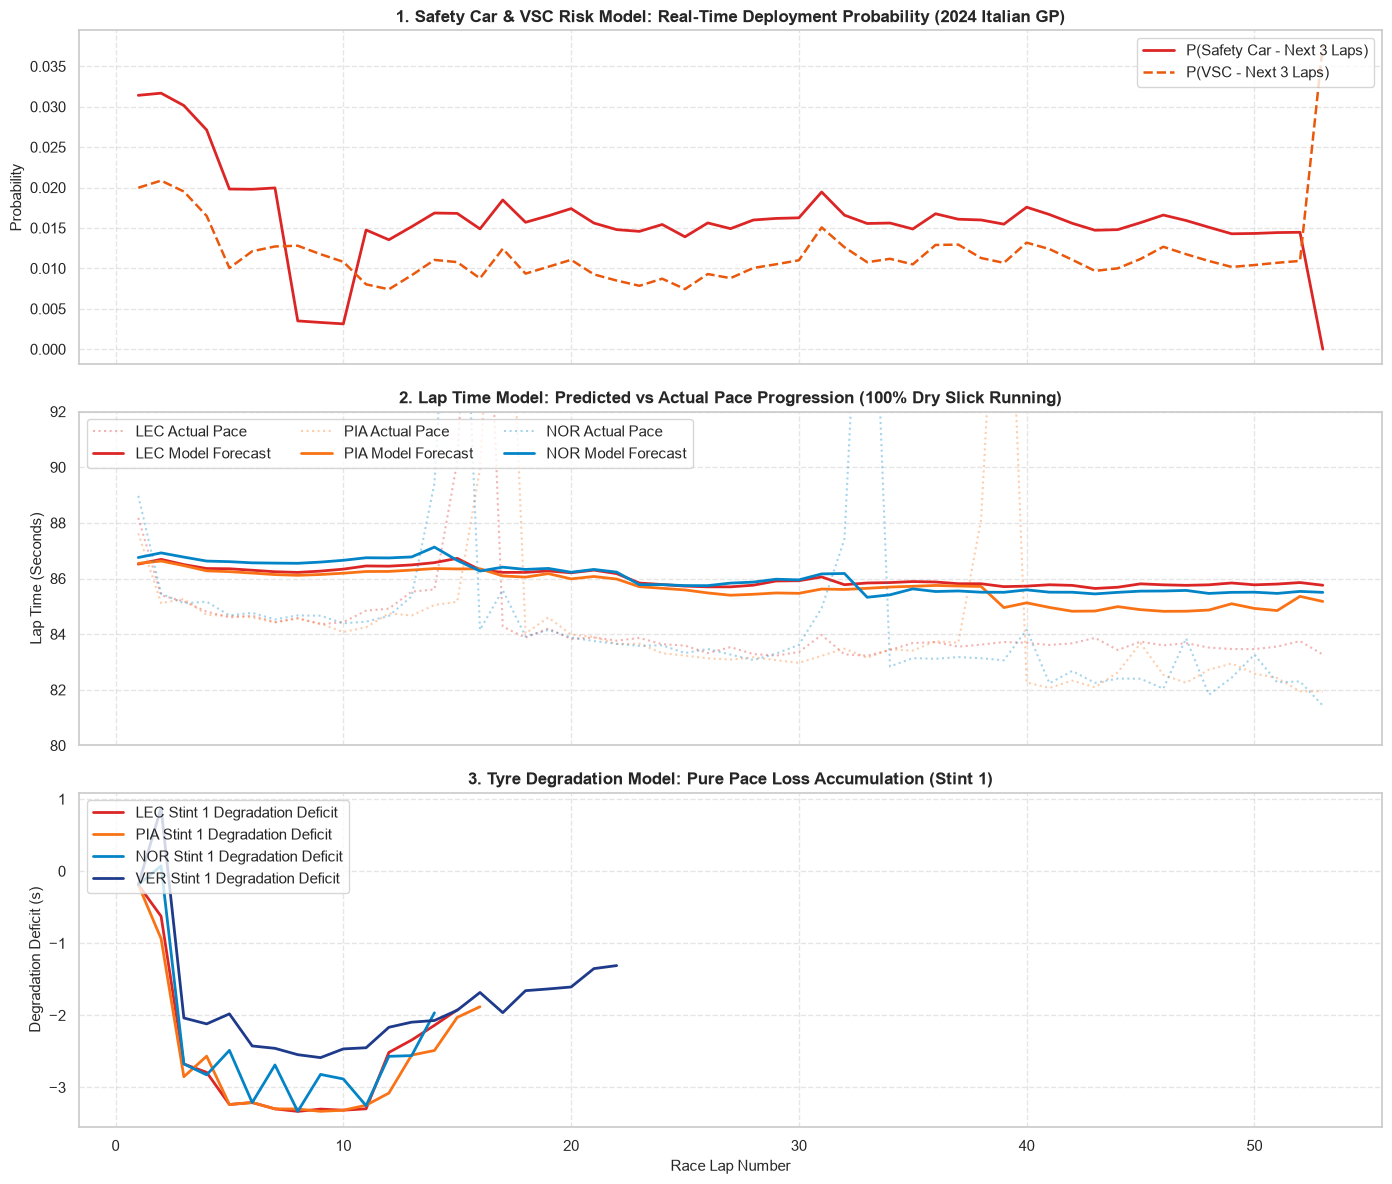

Multi-model post-race analytics visualization saved to outputs\plots\visualizer_multi_model_replay_analytics.png


In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set light mode aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid')

# Compile historical metrics from all_model_snapshots
sc_rows = []
driver_rows = []

for snap in all_model_snapshots:
    lap = snap['current_lap']
    cond = snap['current_conditions']
    sc_info = snap.get('sc_risk', {}).get('SC_probs', {})
    vsc_info = snap.get('sc_risk', {}).get('VSC_probs', {})
    
    sc_rows.append({
        'LapNumber': lap,
        'P_SC_3L': sc_info.get('3L', 0.0),
        'P_VSC_3L': vsc_info.get('3L', 0.0),
        'Has_SC': cond.get('has_safety_car', False),
        'Has_VSC': cond.get('has_vsc', False),
        'Rainfall': cond.get('rainfall', False),
    })
    
    lt_dict = snap.get('predictions', {}).get('lap_time_seconds', {})
    td_dict = snap.get('predictions', {}).get('tyre_deg_deficit_seconds', {})
    
    for driver_code in ['LEC', 'PIA', 'NOR', 'SAI', 'HAM', 'VER']:
        p = snap.get('participants', {}).get(driver_code)
        if p:
            driver_rows.append({
                'LapNumber': lap,
                'Driver': driver_code,
                'ActualLapTime': p.get('last_lap_time_seconds'),
                'PredLapTime': lt_dict.get(driver_code),
                'PredTyreDeg': td_dict.get(driver_code),
                'Compound': p.get('compound'),
                'Stint': p.get('stint', 1),
                'TyreLife': p.get('tyre_life', 0),
            })

df_sc_hist = pd.DataFrame(sc_rows)
df_driver_hist = pd.DataFrame(driver_rows)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Safety Car Risk Progression
axes[0].plot(df_sc_hist['LapNumber'], df_sc_hist['P_SC_3L'], color='#dc2626', lw=2, label='P(Safety Car - Next 3 Laps)')
axes[0].plot(df_sc_hist['LapNumber'], df_sc_hist['P_VSC_3L'], color='#ea580c', lw=1.8, linestyle='--', label='P(VSC - Next 3 Laps)')
axes[0].set_ylabel('Probability', fontsize=11)
axes[0].set_title('1. Safety Car & VSC Risk Model: Real-Time Deployment Probability (2024 Italian GP)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Lap Time Predictions vs Actual Pace
driver_colors = {'LEC': '#dc2626', 'PIA': '#f97316', 'NOR': '#0284c7', 'VER': '#1e3a8a', 'HAM': '#059669', 'SAI': '#eab308'}
for d in ['LEC', 'PIA', 'NOR']:
    sub = df_driver_hist[df_driver_hist['Driver'] == d]
    if not sub.empty:
        axes[1].plot(sub['LapNumber'], sub['ActualLapTime'], color=driver_colors[d], lw=1.5, alpha=0.35, linestyle=':', label=f'{d} Actual Pace')
        axes[1].plot(sub['LapNumber'], sub['PredLapTime'], color=driver_colors[d], lw=2, label=f'{d} Model Forecast')

axes[1].set_ylabel('Lap Time (Seconds)', fontsize=11)
axes[1].set_ylim(80, 92)
axes[1].set_title('2. Lap Time Model: Predicted vs Actual Pace Progression (100% Dry Slick Running)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', ncol=3, frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Pure Tyre Degradation Deficit Accumulation
for d in ['LEC', 'PIA', 'NOR', 'VER']:
    sub = df_driver_hist[(df_driver_hist['Driver'] == d) & (df_driver_hist['Stint'] == 1)]
    if not sub.empty:
        axes[2].plot(sub['LapNumber'], sub['PredTyreDeg'], color=driver_colors[d], lw=2, label=f'{d} Stint 1 Degradation Deficit')

axes[2].set_xlabel('Race Lap Number', fontsize=11)
axes[2].set_ylabel('Degradation Deficit (s)', fontsize=11)
axes[2].set_title('3. Tyre Degradation Model: Pure Pace Loss Accumulation (Stint 1)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper left', frameon=True)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plot_path = os.path.join('outputs', 'plots', 'visualizer_multi_model_replay_analytics.png')
plt.savefig(plot_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Multi-model post-race analytics visualization saved to {plot_path}")
